# Setup

In [1]:
!nvidia-smi

Thu Nov 20 04:08:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# RUN

In [ ]:
from run_bayesian_vs_nonbayesian import run_multi_dataset_comparison 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


# ============ MODE 3: MULTI-DATASET (All 3 Datasets) ============
print("\n" + "="*80)
print("MODE 3: MULTI-DATASET COMPARISON")
print("="*80)

all_results = run_multi_dataset_comparison(
    datasets=['IXIC', 'DJI', 'NYSE'],
    epochs=500,
    early_stop_patience=10,
    batch_size=32,
    learning_rate=0.001,
    hidden_dim=64,
    R=3, K=3, d_e=10, heads=4,
    mc_train=7, mc_eval=35,
    verbose=True,
    log_base_dir='logs',
    device=device
)

print("\n" + "="*80)
print("✓ MULTI-DATASET COMPARISON COMPLETED!")
print("="*80)
print("\nResults saved to: logs/bayesian_vs_nonbayesian/")
print("\nTo generate comparison plots, run:")
print("  from utils.result_plot import plot_bayesian_vs_nonbayesian_comparison")
print("  plot_bayesian_vs_nonbayesian_comparison('logs/bayesian_vs_nonbayesian')")

Using device: cuda

MODE 3: MULTI-DATASET COMPARISON
MULTI-DATASET BAYESIAN VS NON-BAYESIAN COMPARISON
Study: bayesian_vs_nonbayesian_20251120_041442
Datasets: IXIC, DJI, NYSE
Models: BIMamba-MAGAC (Bayesian vs Non-Bayesian)

Processing IXIC...
BAYESIAN VS NON-BAYESIAN COMPARISON - IXIC
Study: bayesian_vs_nonbayesian_20251120_041442
Architecture: R=3, K=3, heads=4, mc_train=7, mc_eval=35
Loss: Non-Bayesian=Huber, Bayesian=GaussianNLL
Training: LR=0.001, Epochs=500, Grad Clip=True (max_norm=5.0)
Scheduler: MultiStepLR (milestones=[40, 60, 80], gamma=0.1)

Loading data...
 Data shape: (3470, 82)
NaN distribution:
 Price       0
Vol.        0
weekday     0
mom         0
mom1        0
           ..
DE1        23
DE2        28
DE4        28
DE5        28
DE6        28
Length: 82, dtype: int64
 FILLNA BY MEDIAN - Data shape: (3470, 82)
✓ Data loaded: 81 features
  Train: 2772 samples
  Val:   173 samples
  Test:  520 samples

Creating models...

TRAINING NON-BAYESIAN MODEL
Loss function: Det

/tmp/ipython-input-173138017.py:865: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(confidence, errors)


✓ Data loaded: 81 features
  Train: 2772 samples
  Val:   173 samples
  Test:  520 samples

Creating models...

TRAINING NON-BAYESIAN MODEL
Loss function: Deterministic (auto → Huber for MAMBA variants)
Reason: Fixed variance, no MC sampling
Gradient clipping: ENABLED (max_norm=5.0) - prevents gradient instability
LR scheduler: MultiStepLR - improves convergence
BAYESIAN_VS_NONBAYESIAN_20251120_041442 TRAINING - Unified Pipeline
Dataset: DJI
Models: BIMamba-MAGAC_NonBayesian
Config: {'epochs': 500, 'lr': 0.001, 'loss_type': 'auto', 'patience': 10, 'optimizer_fn': <function run_comparison.<locals>.<lambda> at 0x7918303de7a0>, 'scheduler_fn': None, 'grad_clip': True, 'max_grad_norm': 5.0}
Device: cuda

Training: BIMamba-MAGAC_NonBayesian
✓ New best model (Val Loss: 0.000033)
✓ New best model (Val Loss: 0.000031)
Epoch 5/500 - Train: 0.000144, Val: 0.000028, RMSE: 0.007384, IC: 0.4800, Time: 7.43s
✓ New best model (Val Loss: 0.000028)
✓ New best model (Val Loss: 0.000021)
✓ New best model

/tmp/ipython-input-173138017.py:865: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(confidence, errors)


✓ Data loaded: 81 features
  Train: 2772 samples
  Val:   173 samples
  Test:  520 samples

Creating models...

TRAINING NON-BAYESIAN MODEL
Loss function: Deterministic (auto → Huber for MAMBA variants)
Reason: Fixed variance, no MC sampling
Gradient clipping: ENABLED (max_norm=5.0) - prevents gradient instability
LR scheduler: MultiStepLR - improves convergence
BAYESIAN_VS_NONBAYESIAN_20251120_041442 TRAINING - Unified Pipeline
Dataset: NYSE
Models: BIMamba-MAGAC_NonBayesian
Config: {'epochs': 500, 'lr': 0.001, 'loss_type': 'auto', 'patience': 10, 'optimizer_fn': <function run_comparison.<locals>.<lambda> at 0x7919a4b44c20>, 'scheduler_fn': None, 'grad_clip': True, 'max_grad_norm': 5.0}
Device: cuda

Training: BIMamba-MAGAC_NonBayesian
✓ New best model (Val Loss: 0.000093)
✓ New best model (Val Loss: 0.000073)
✓ New best model (Val Loss: 0.000050)
✓ New best model (Val Loss: 0.000042)
Epoch 5/500 - Train: 0.000092, Val: 0.000032, RMSE: 0.007969, IC: 0.4240, Time: 7.41s
✓ New best mode

/tmp/ipython-input-173138017.py:865: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(confidence, errors)



CROSS-SECTIONAL IC ANALYSIS (Multi-Asset)
Assets analyzed: IXIC, DJI, NYSE
Valid trading days: 520

Cross-Sectional Information Coefficient (IC):
  Mean:       0.470991
  Std:        0.660168
  Median:     0.826465
  % Positive: 77.1%

Cross-Sectional Rank IC (RIC):
  Mean:       0.396154
  Std:        0.647320
  Median:     0.500000
  % Positive: 75.4%

📊 INTERPRETATION:
   🔥 EXCEPTIONAL: IC > 0.05 is extremely rare in real markets!

NOTE: Cross-sectional IC measures correlation ACROSS ASSETS at each
      time point, unlike single-asset IC which measures correlation
      across TIME for a single asset.

  Comparing single-asset vs cross-sectional IC...

COMPARISON: Single-Asset (Time-Series) vs Cross-Sectional IC

Single-Asset IC: Correlation of predictions vs actuals ACROSS TIME
                 for each individual asset (usually high ~0.3-0.9)

Cross-Sectional IC: Correlation of predictions vs actuals ACROSS ASSETS
                    at each time point (usually low ~0.01-0.05)



In [14]:
ls logs

bayesian_vs_nonbayesian_20251119_065456/
bayesian_vs_nonbayesian_20251119_083350/
bayesian_vs_nonbayesian_20251120_041201/
bayesian_vs_nonbayesian_20251120_041442/
mamba_gnn/
tuneparams.txt


Generating comparison plots for datasets: ['DJI_summary_20251120_043016', 'NYSE', 'IXIC', 'NYSE_summary_20251120_043807', 'IXIC_summary_20251120_041444', 'IXIC_summary_20251120_041919', 'DJI_summary_20251120_042551', 'NYSE_summary_20251120_043535', 'DJI']

Processing DJI_summary_20251120_043016...
  Model directories not found for DJI_summary_20251120_043016, skipping...

Processing NYSE...
  Generating metric comparison...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/NYSE/comparison_plots/metrics_comparison.png
  Generating uncertainty comparison...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/NYSE/comparison_plots/uncertainty_comparison.png
  Generating calibration comparison...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/NYSE/comparison_plots/calibration_comparison.png
  Generating prediction comparison...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/NYSE/comparison_plots/prediction_comparison.png
  Generating regime analysis...


/tmp/ipython-input-1438485582.py:381: RuntimeWarning: Mean of empty slice.
  nb_errors = [error_nb[regime == i].mean() for i in range(3)]
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-1438485582.py:382: RuntimeWarning: Mean of empty slice.
  b_errors = [error_b[regime == i].mean() for i in range(3)]
/tmp/ipython-input-1438485582.py:396: RuntimeWarning: Mean of empty slice.
  nb_sigmas = [df_nb['sigma'].values[regime == i].mean() for i in range(3)]
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-1438485582.py:397: RuntimeWarning: Mean of empty slice.
  b_sigmas = [df_b['sigma'].values[regime == i].mean() for i in range(3)]


Saved: logs/bayesian_vs_nonbayesian_20251120_041442/NYSE/comparison_plots/regime_analysis.png
  Generating confidence-accuracy curve...


/tmp/ipython-input-1438485582.py:679: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = spearmanr(confidence, errors)


Saved: logs/bayesian_vs_nonbayesian_20251120_041442/NYSE/comparison_plots/confidence_accuracy_curve.png
  Generating risk-adjusted returns...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/NYSE/comparison_plots/risk_adjusted_returns.png
  Generating uncertainty contribution...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/NYSE/comparison_plots/uncertainty_contribution.png
  Generating sharpness-calibration tradeoff...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/NYSE/comparison_plots/sharpness_calibration_tradeoff.png
  ✓ All plots saved to: logs/bayesian_vs_nonbayesian_20251120_041442/NYSE/comparison_plots

Processing IXIC...
  Generating metric comparison...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/IXIC/comparison_plots/metrics_comparison.png
  Generating uncertainty comparison...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/IXIC/comparison_plots/uncertainty_comparison.png
  Generating calibration comparison...
Saved: logs/bayesian_vs_nonbayesian_2

...

Saved: logs/bayesian_vs_nonbayesian_20251120_041442/IXIC/comparison_plots/confidence_accuracy_curve.png
  Generating risk-adjusted returns...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/IXIC/comparison_plots/risk_adjusted_returns.png
  Generating uncertainty contribution...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/IXIC/comparison_plots/uncertainty_contribution.png
  Generating sharpness-calibration tradeoff...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/IXIC/comparison_plots/sharpness_calibration_tradeoff.png
  ✓ All plots saved to: logs/bayesian_vs_nonbayesian_20251120_041442/IXIC/comparison_plots

Processing NYSE_summary_20251120_043807...
  Model directories not found for NYSE_summary_20251120_043807, skipping...

Processing IXIC_summary_20251120_041444...
  Model directories not found for IXIC_summary_20251120_041444, skipping...

Processing IXIC_summary_20251120_041919...
  Model directories not found for IXIC_summary_20251120_041919, skipping...

Proces

/tmp/ipython-input-1438485582.py:381: RuntimeWarning: Mean of empty slice.
  nb_errors = [error_nb[regime == i].mean() for i in range(3)]
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-1438485582.py:382: RuntimeWarning: Mean of empty slice.
  b_errors = [error_b[regime == i].mean() for i in range(3)]
/tmp/ipython-input-1438485582.py:396: RuntimeWarning: Mean of empty slice.
  nb_sigmas = [df_nb['sigma'].values[regime == i].mean() for i in range(3)]
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-1438485582.py:397: RuntimeWarning: Mean of empty slice.
  b_sigmas = [df_b['sigma'].values[regime == i].mean() for i in range(3)]


Saved: logs/bayesian_vs_nonbayesian_20251120_041442/DJI/comparison_plots/regime_analysis.png
  Generating confidence-accuracy curve...


/tmp/ipython-input-1438485582.py:679: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = spearmanr(confidence, errors)


Saved: logs/bayesian_vs_nonbayesian_20251120_041442/DJI/comparison_plots/confidence_accuracy_curve.png
  Generating risk-adjusted returns...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/DJI/comparison_plots/risk_adjusted_returns.png
  Generating uncertainty contribution...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/DJI/comparison_plots/uncertainty_contribution.png
  Generating sharpness-calibration tradeoff...
Saved: logs/bayesian_vs_nonbayesian_20251120_041442/DJI/comparison_plots/sharpness_calibration_tradeoff.png
  ✓ All plots saved to: logs/bayesian_vs_nonbayesian_20251120_041442/DJI/comparison_plots

✓ All comparison plots generated!

✓ Plots generated!
Study directory not found: logs/bayesian_vs_nonbayesian_20251120_041442/bayesian_vs_nonbayesian
No matching directories found with pattern bayesian_vs_nonbayesian_*
COMPREHENSIVE ANALYSIS - BAYESIAN VS NON-BAYESIAN

Datasets analyzed: DJI, DJI_summary_20251120_042551, DJI_summary_20251120_043016, IXIC, IXIC_summary_

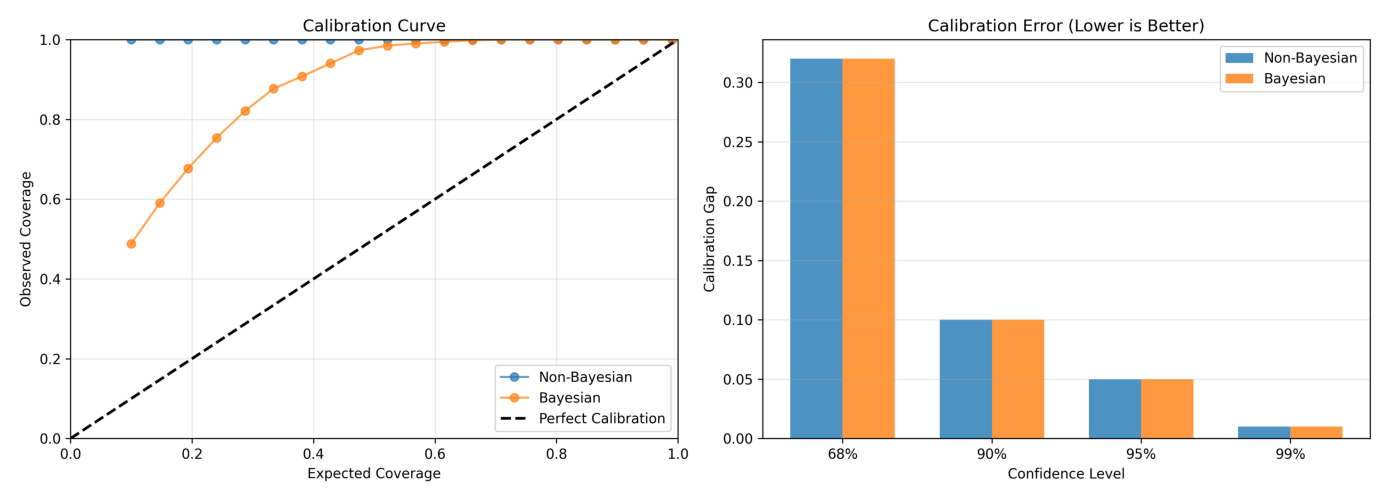


confidence_accuracy_curve.png
--------------------------------------------------------------------------------


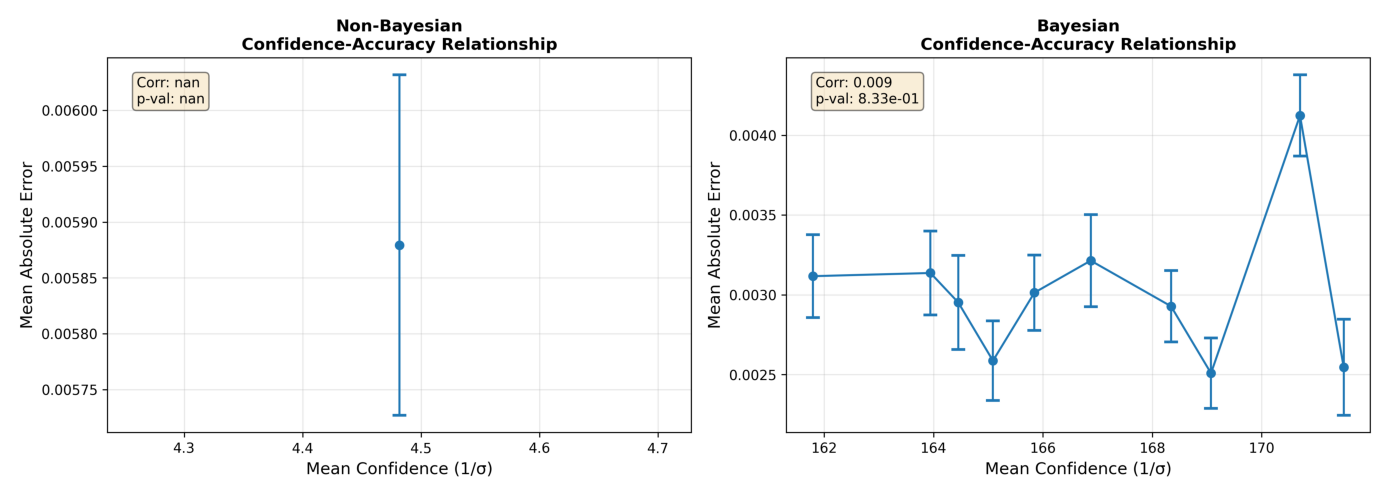


metrics_comparison.png
--------------------------------------------------------------------------------


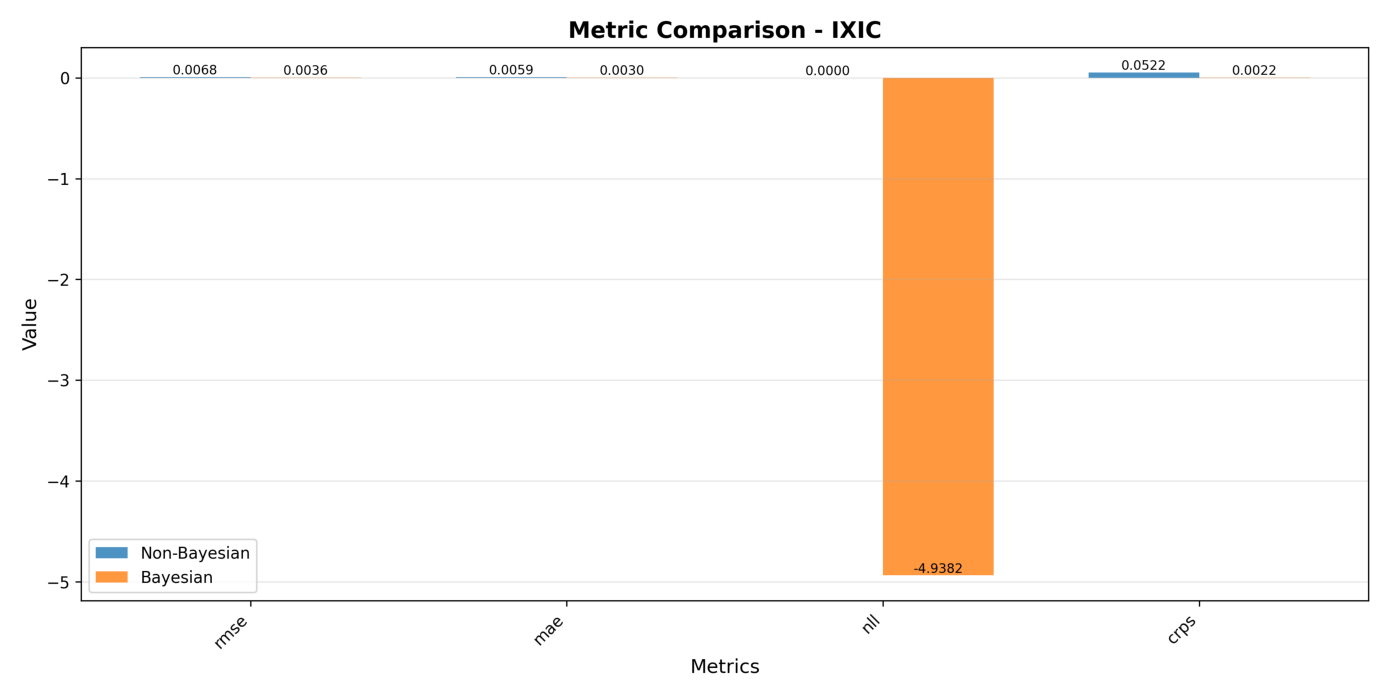


prediction_comparison.png
--------------------------------------------------------------------------------


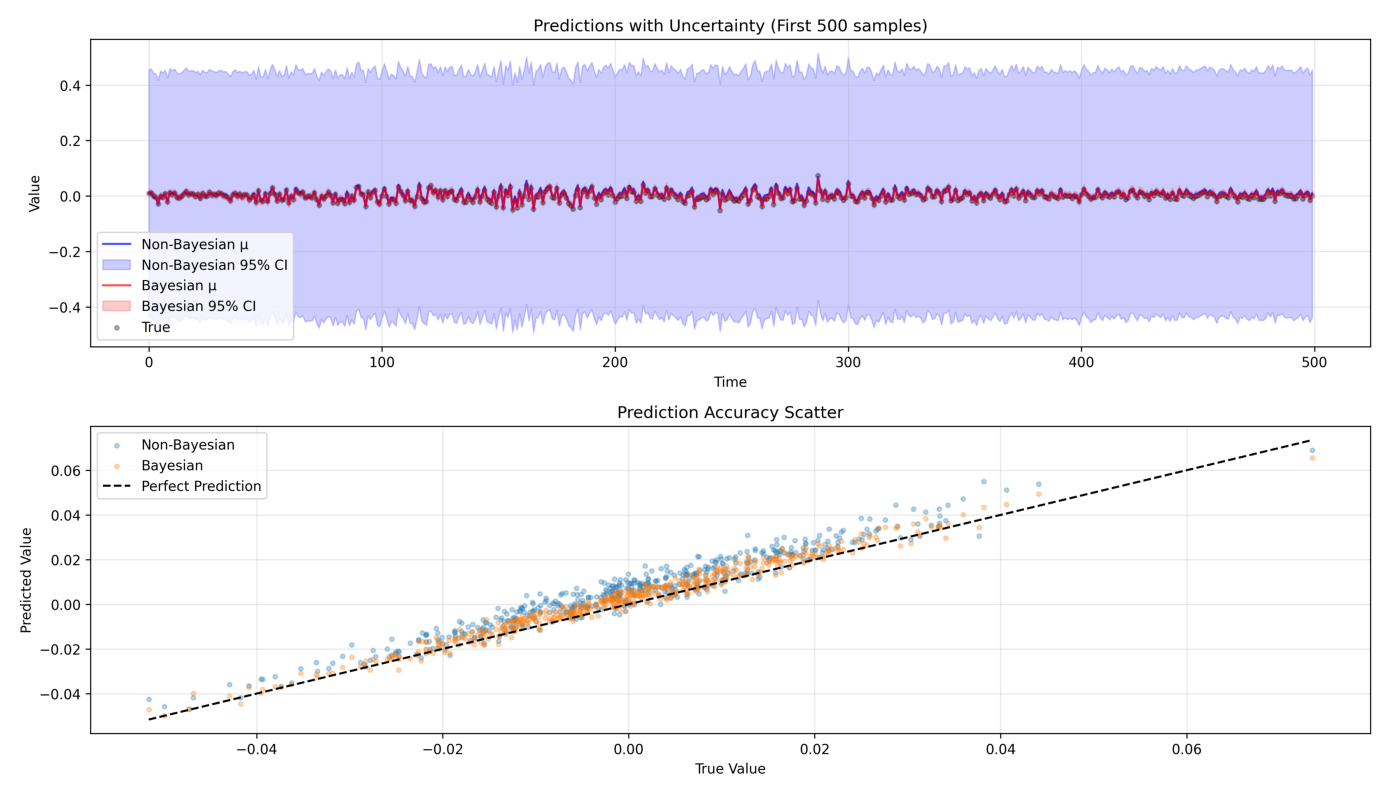


regime_analysis.png
--------------------------------------------------------------------------------


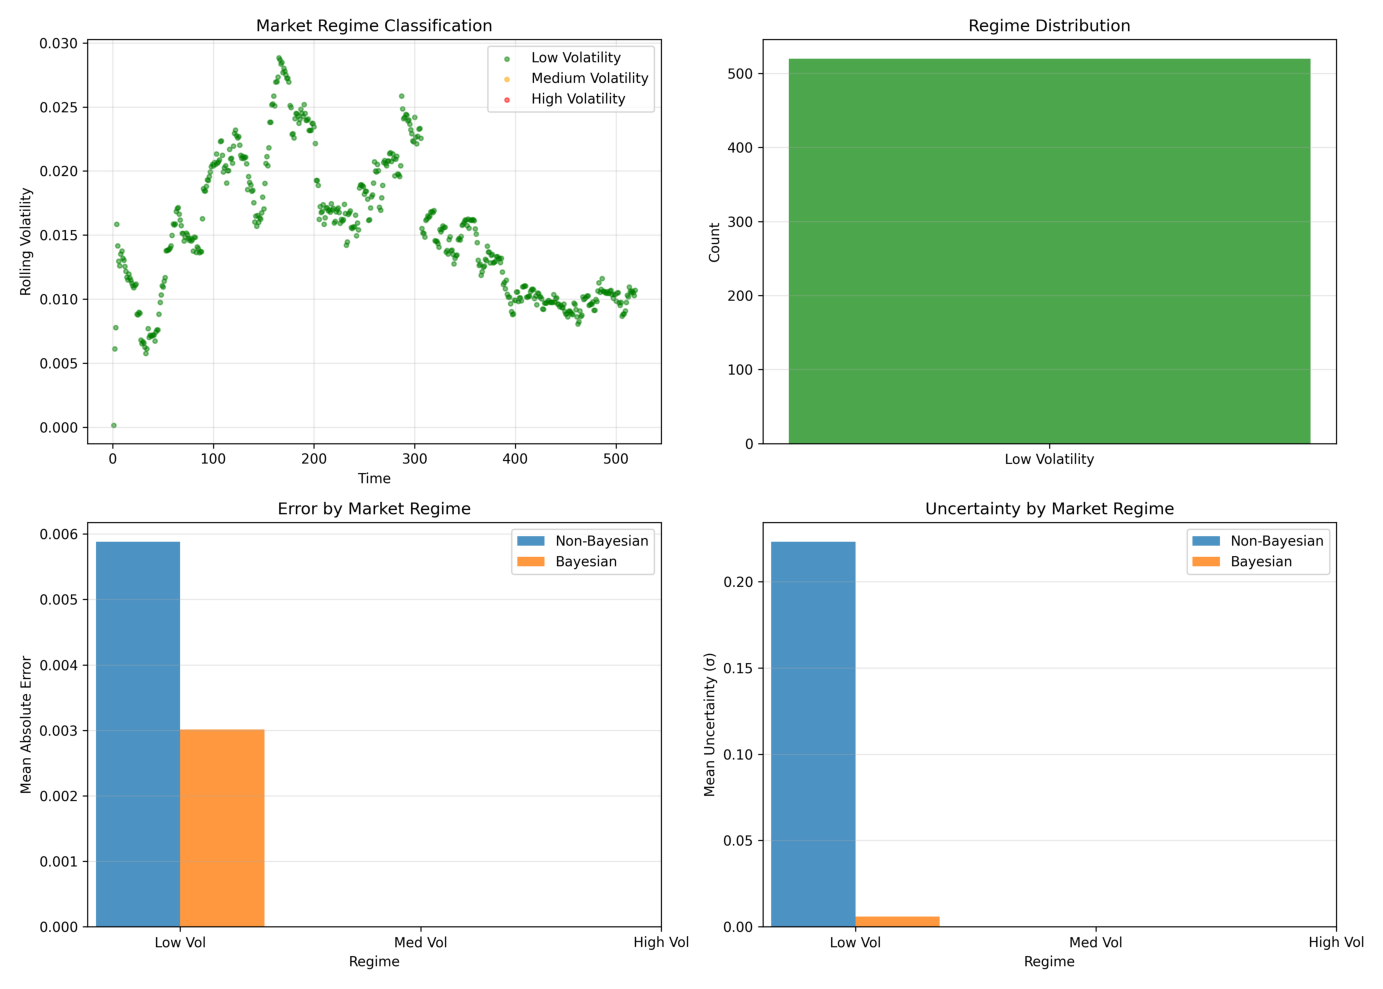


risk_adjusted_returns.png
--------------------------------------------------------------------------------


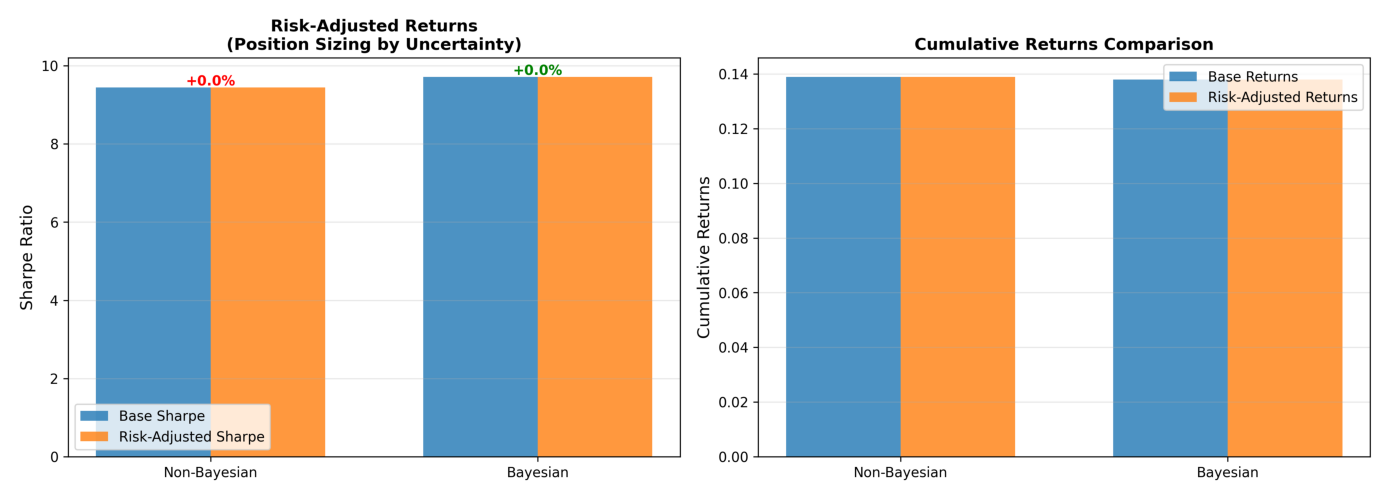


sharpness_calibration_tradeoff.png
--------------------------------------------------------------------------------


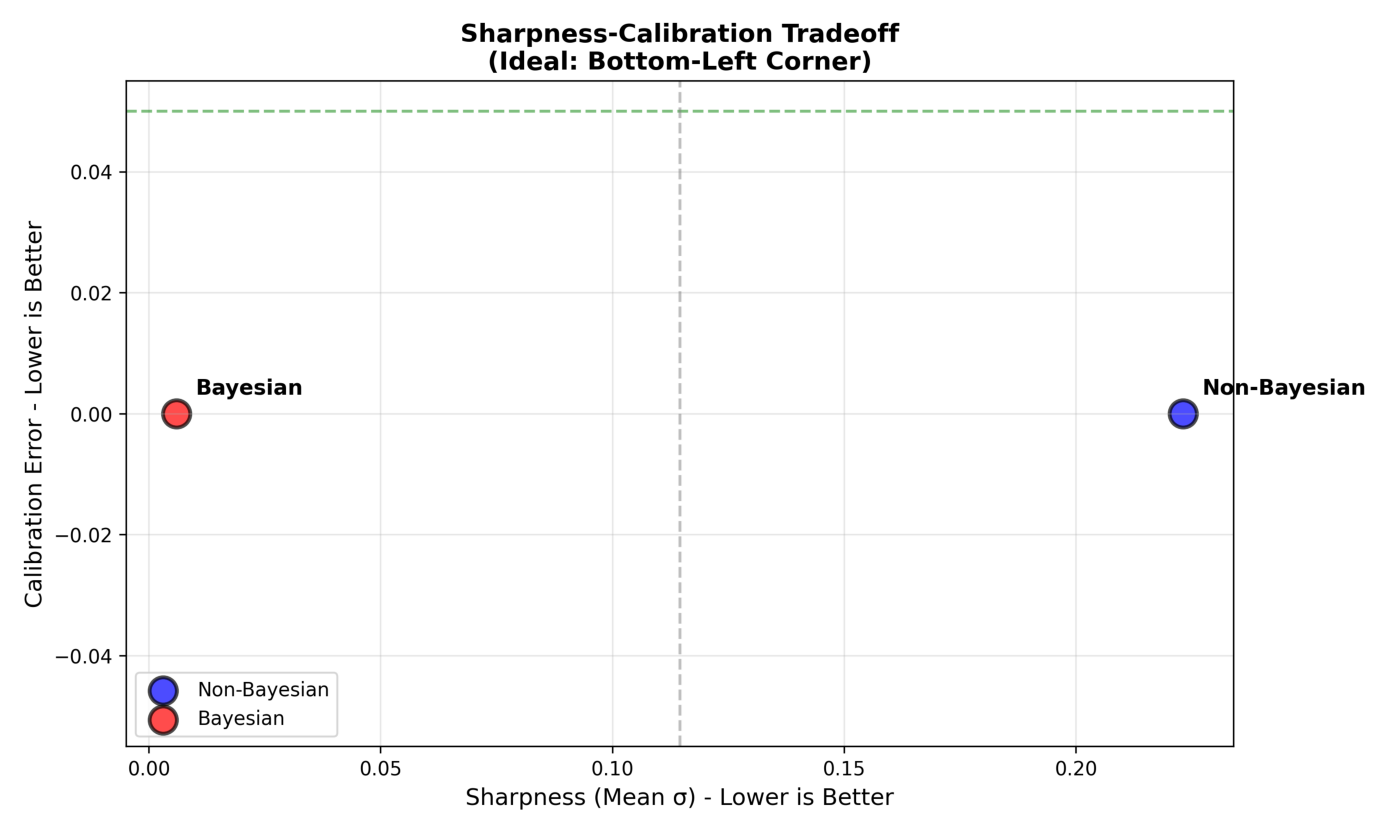


uncertainty_comparison.png
--------------------------------------------------------------------------------


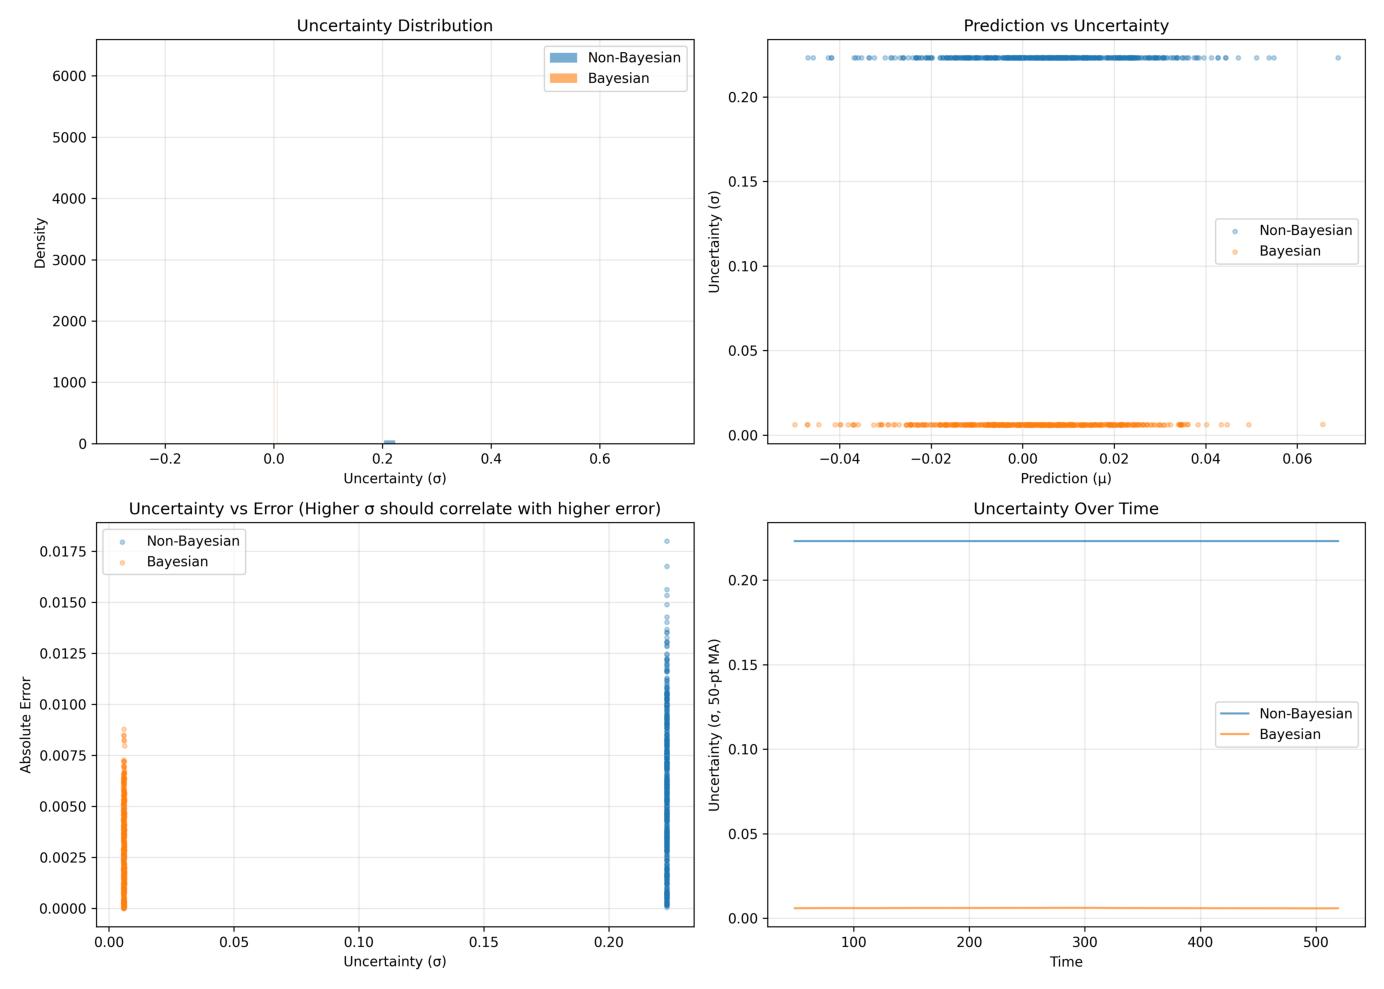


uncertainty_contribution.png
--------------------------------------------------------------------------------


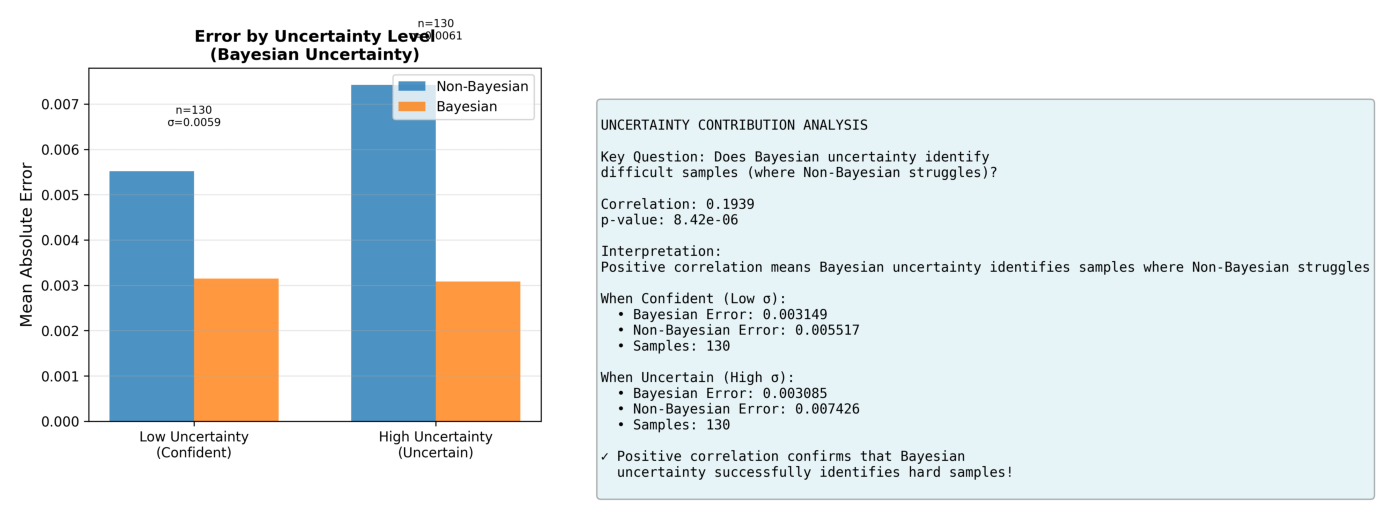

✓ Displayed all 9 plots

✓ COMPLETE WORKFLOW FINISHED!

Results saved to:
  - Training results: logs/bayesian_vs_nonbayesian_20251120_041442/
  - Plots: logs/bayesian_vs_nonbayesian_20251120_041442/*/comparison_plots/
  - Analysis: logs/bayesian_vs_nonbayesian_20251120_041442/comprehensive_analysis_report.txt
  - Cross-sectional IC: logs/bayesian_vs_nonbayesian_20251120_041442/cross_sectional_ic_summary.txt


In [15]:
# 2. Generate all plots
# from utils.result_plot import plot_bayesian_vs_nonbayesian_comparison
study_dir = "bayesian_vs_nonbayesian_20251120_041442"
plot_bayesian_vs_nonbayesian_comparison(
    base_dir=f'logs/{study_dir}',
    dataset=None  # All datasets
)
print("\n✓ Plots generated!")

# 3. List all plots
# from utils.result_plot import list_all_plots
plot_inventory = list_all_plots(
    base_dir=f'logs/{study_dir}',
    study_name="bayesian_vs_nonbayesian"
)

# 4. Generate comprehensive analysis
# from utils.result_plot import generate_comprehensive_analysis
analysis = generate_comprehensive_analysis(
    base_dir='logs',
    study_name=study_dir,
    output_file=f'logs/{study_dir}/comprehensive_analysis_report.txt'
)
print("\n✓ Analysis completed!")

# 5. Print key findings
print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)
for i, conclusion in enumerate(analysis['conclusions'], 1):
    print(f"\n{i}. {conclusion}")

# 6. Display plots in notebook (optional)
# from utils.result_plot import display_all_plots
# Display plots for IXIC dataset
display_all_plots(
    plot_dir=f'logs/{study_dir}/IXIC/comparison_plots',
    image_size=(14, 10)
)

print("\n" + "="*80)
print("✓ COMPLETE WORKFLOW FINISHED!")
print("="*80)
print("\nResults saved to:")
print(f"  - Training results: logs/{study_dir}/")
print(f"  - Plots: logs/{study_dir}/*/comparison_plots/")
print(f"  - Analysis: logs/{study_dir}/comprehensive_analysis_report.txt")
print(f"  - Cross-sectional IC: logs/{study_dir}/cross_sectional_ic_summary.txt")